NBA Player Salaries - Who's Overpaid and Underpaid?
- Which players are overpaid or underpaid in 2025?
- What factors determine player salaries?

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('NBA Player Stats and Salaries_2000-2025.csv')

In [5]:
df.columns

Index(['Player', 'Salary', 'Year', 'Pos', 'Age', 'Team', 'G', 'GS', 'MP', 'FG',
       'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT',
       'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS'],
      dtype='object')

Feature Glossary (common columns like Player, Salary, Year, Age, Team, and PTS are not included)
- Pos - Player position (PG, SG, SF, PF, C)
- G - Games played
- GS - Games started
- MP - Minutes played per game
- FG - Field goals made per game
- FGA - Field goals attempted per game
- FG% - Field goal percentage
- 3P - Three-pointers made per game
- 3PA - Three-pointers attempted per game
- 3P% - Three-point percentage
- 2P - Two-pointers made per game
- 2PA - Two-pointers attempted per game
- 2P% - Two-point percentage
- eFG% - Effective field goal percentage
- FT - Free throws made per game
- FTA - Free throws attempted per game
- FT% - Free throw percentage
- ORB - Offensive rebounds per game
- DRB - Defensive rebounds per game
- TRB - Total rebounds per game
- AST - Assists per game
- STL - Steals per game
- BLK - Blocks per game
- TOV - Turnovers per game
- PF - Personal fouls per game


In [6]:
# Because I don't want to randomly test, I can't use a Train/Test split.
# So I used pre-2025 data to train and test on 2025 data
# Create features and target for the whole dataset
X = df.drop(columns=['Salary', 'Player', 'Team', 'Pos'])
y = df['Salary']

# Split by year: train on past seasons, test on 2025
X_train = X[df['Year'] < 2025]
y_train = y[df['Year'] < 2025]

X_test = X[df['Year'] == 2025]
y_test = y[df['Year'] == 2025]

Cleaning Data:
- Filled in missing values with 0 if the player had 0 attempts.
- Dropped any remaining rows with missing values, while most missing values are handled, this just guarantees no errors


In [7]:
# Find all missing values
print(df.isnull().sum())


Player       0
Salary       0
Year         0
Pos          0
Age          0
Team         0
G            0
GS           0
MP           0
FG           0
FGA          0
FG%         21
3P           0
3PA          0
3P%       1106
2P           0
2PA          0
2P%         49
eFG%        21
FT           0
FTA          0
FT%        251
ORB          0
DRB          0
TRB          0
AST          0
STL          0
BLK          0
TOV          0
PF           0
PTS          0
dtype: int64


In [8]:
# Check if the people with missing values have even taken any attempts if no attempts fill with 0

# For FG%
df[df['FG%'].isna()][['Player', 'FGA']]
df.loc[(df['FG%'].isna()) & (df['FGA'] == 0), 'FG%'] = 0

#For 3P%
df[df['3P%'].isna()][['Player', '3PA']]
df.loc[(df['3P%'].isna()) & (df['3PA'] == 0), '3P%'] = 0

#For 2P%
df[df['2P%'].isna()][['Player', '2PA']]
df.loc[(df['2P%'].isna()) & (df['2PA'] == 0), '2P%'] = 0

#For eFG%
df[df['eFG%'].isna()][['Player', 'FGA', '3PA', 'FG']]
df.loc[(df['eFG%'].isna()) & (df['FGA'] == 0), 'eFG%'] = 0

#For FT%
df[df['FT%'].isna()][['Player', 'FTA']]
df.loc[(df['FT%'].isna()) & (df['FTA'] == 0), 'FT%'] = 0

# Drop any remaining rows with NaN values to ensure a clean dataset for the model
df.dropna(inplace=True)


In [9]:
# fill any remaining missing values in the training and test data with 0.
# So we don't encounter errors from NaN values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# use a linear regression model
model = LinearRegression()
model.fit(X_train, y_train) # train the model using training data

y_pred = model.predict(X_test) # using the trained model to predict salaries for the test set
# take square root so we can get the actual amount each prediction are from actual values
Sqrt_MSE = np.sqrt(mean_squared_error(y_test, y_pred))

print("Sqrt(MSE):", round(Sqrt_MSE, 2))
print("R²:", r2_score(y_test, y_pred)) # find r2 score to check fit

Sqrt(MSE): 8456234.67
R²: 0.5385794419393124


In [ ]:
# use a random forest regressor model
rf = RandomForestRegressor(
    n_estimators=200,  # more estimates usually improves performance
    max_depth=10,      # depth of each tree
    random_state=42
)
#train data
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
Sqrt_MSE_RF = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Sqrt(MSE):", round(Sqrt_MSE_RF, 2))
print("R²:", r2)

Most important factors in NBA Salaries based on the Random Forest model, the top features influencing salaries are:
- PTS
- Age
- Year
- Minutes Played
- Field Goals

In [11]:
# Since the Random Forest Regressor is more accurate let's use that one to test what the most important when deciding NBA salaries
important = rf.feature_importances_
features = X_train.columns

# create a dataset and pair each feature with its importance score
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': important
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10)) # we only want to look at the top 10


   Feature  Importance
26     PTS    0.329775
1      Age    0.179146
0     Year    0.176320
4       MP    0.064881
5       FG    0.025463
19     DRB    0.021702
21     AST    0.015418
24     TOV    0.012884
3       GS    0.012771
11      2P    0.012483


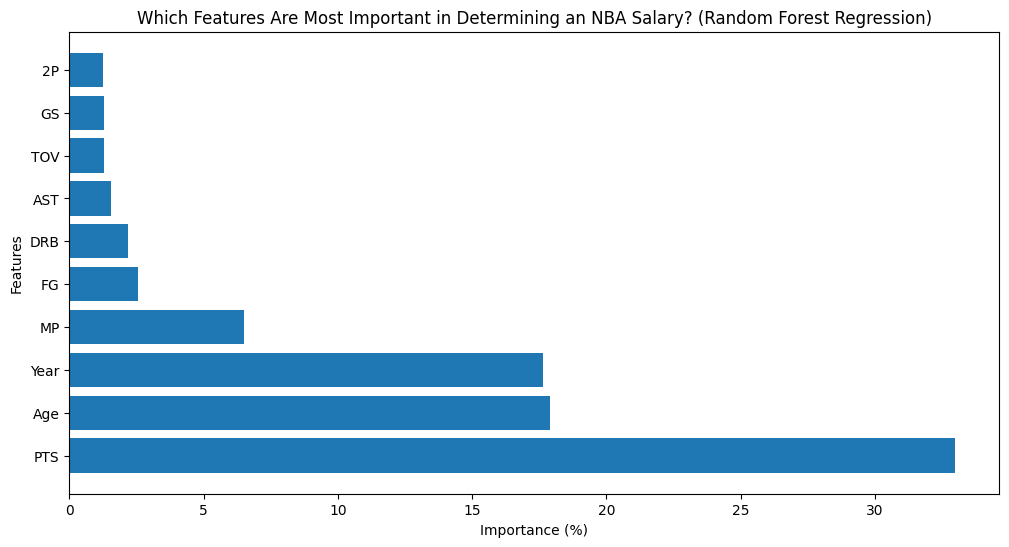

In [12]:
import matplotlib.pyplot as plt

# Convert to percentages
feature_importance_df['Importance_pct'] = feature_importance_df['Importance'] * 100
Top_ten = feature_importance_df['Feature'].head(10)
Top_ten_importance = feature_importance_df['Importance_pct'].head(10)
plt.figure(figsize=(12,6))
plt.barh(Top_ten, Top_ten_importance) # Tried a regular bar chart and think it's easier to understand horizontal
plt.xlabel('Importance (%)')
plt.ylabel('Features')
plt.title('Which Features Are Most Important in Determining an NBA Salary? (Random Forest Regression)')
plt.show()

2025 Salary Predictions vs Actual

Using the Random Forest model, we predicted 2025 NBA player salaries and compared them to the actual salaries:  

- **Top 10 Overpaid Players**: Players with the highest positive difference between actual and predicted salary.  
- **Top 10 Underpaid Players**: Players with the largest negative difference between actual and predicted salary.


In [13]:
# Copy 2025 data
df_2025 = df[df['Year'] == 2025].copy()
X_2025 = X[df['Year'] == 2025]

# Predict salaries
df_2025['Predicted_Salary'] = rf.predict(X_2025)

# Calculate difference and percentage
df_2025['Difference'] = df_2025['Salary'] - df_2025['Predicted_Salary']
df_2025['Predicted_vs_Actual'] = ((df_2025['Difference'] / df_2025['Predicted_Salary']) * 100).round(2)

# Round numbers so they're easier to read
df_2025['Predicted_Salary'] = df_2025['Predicted_Salary'].round(0)
df_2025['Difference'] = df_2025['Difference'].round(0)
df_2025['Predicted_vs_Actual'] = df_2025['Predicted_vs_Actual'].round(2)

# Want to filter out players who are not on regular NBA contracts (Ex: 10 Day Contracts)
df_2025_filtered = df_2025[df_2025['Salary'] > 1100000]

# Overpaid players
overpaid = df_2025_filtered.sort_values(by='Predicted_vs_Actual', ascending=False).head(10)

# Underpaid players
underpaid = df_2025_filtered.sort_values(by='Predicted_vs_Actual', ascending=True).head(10)

# results
print("Top 10 Overpaid Players:")
print(overpaid[['Player', 'Salary', 'Predicted_Salary', 'Difference', 'Predicted_vs_Actual']])
print("\nTop 10 Underpaid Players:")
print(underpaid[['Player', 'Salary', 'Predicted_Salary', 'Difference', 'Predicted_vs_Actual']])


Top 10 Overpaid Players:
                  Player    Salary  Predicted_Salary  Difference  \
10117  Marvin Bagley III  12500000         2039059.0  10460941.0   
10078   Patrick Williams  18000000         4262950.0  13737050.0   
10107       Cole Anthony  12900000         3176385.0   9723615.0   
10143      Reed Sheppard  10098960         2570906.0   7528054.0   
10093     Isaiah Stewart  15000000         3961091.0  11038909.0   
10161         Zeke Nnaji   8888889         2399786.0   6489103.0   
10095  Mitchell Robinson  14318182         3917453.0  10400729.0   
10141        Isaac Okoro  10185186         2823241.0   7361945.0   
10047     Jonathan Isaac  25000000         6944298.0  18055702.0   
10310      James Wiseman   2237691          663455.0   1574236.0   

       Predicted_vs_Actual  
10117               513.03  
10078               322.24  
10107               306.12  
10143               292.82  
10093               278.68  
10161               270.40  
10095               265

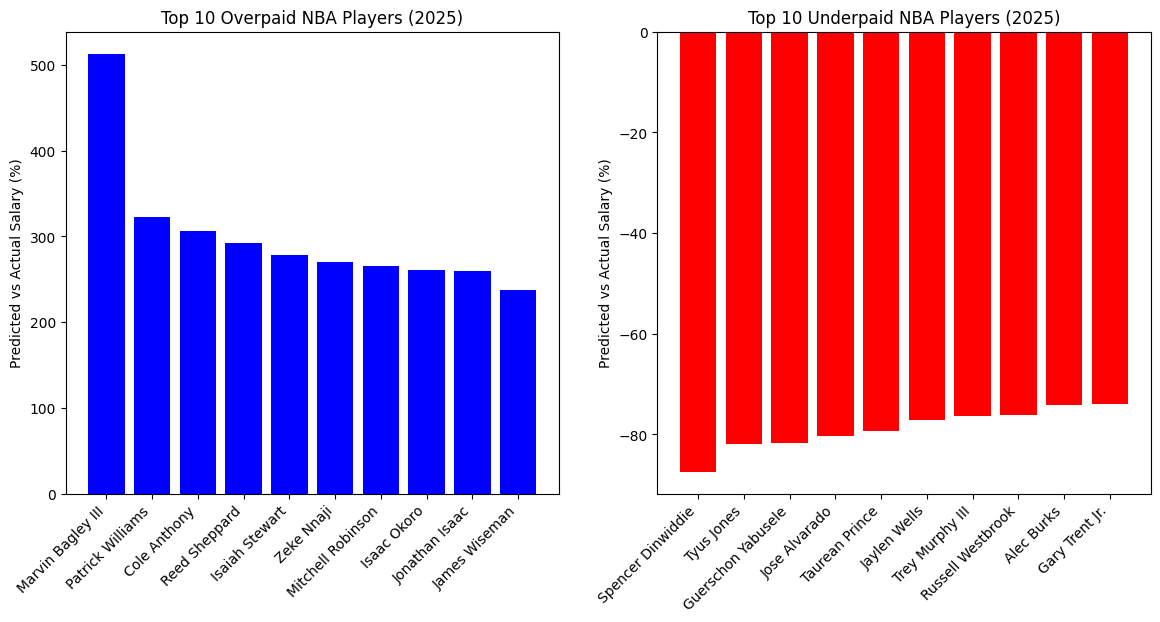

In [14]:
# taking our results from overpaid and underpaid players create a visual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
# overpaid players in blue
ax1.bar(overpaid['Player'], overpaid['Predicted_vs_Actual'], color='blue')
ax1.set_title('Top 10 Overpaid NBA Players (2025)')
ax1.set_ylabel('Predicted vs Actual Salary (%)')
ax1.set_xticks(range(len(overpaid)))
ax1.set_xticklabels(overpaid['Player'], rotation=45, ha='right')
# underpaid players in red
ax2.bar(underpaid['Player'], underpaid['Predicted_vs_Actual'], color='red')
ax2.set_title('Top 10 Underpaid NBA Players (2025)')
ax2.set_ylabel('Predicted vs Actual Salary (%)')
ax2.set_xticks(range(len(underpaid)))
ax2.set_xticklabels(underpaid['Player'], rotation=45, ha='right')
plt.show()





In [15]:
# Compare how positions are being paid
players_2025 = df_2025_filtered.copy()

# Create a overpaid section
players_2025['Overpaid'] = players_2025['Predicted_vs_Actual'] > 0 # greater than 0 means overpaid

# Count total and overpaid by position
positions = players_2025['Pos'].unique()
for pos in positions:
    pos_players = players_2025[players_2025['Pos'] == pos]
    total = len(pos_players)
    overpaid = pos_players['Overpaid'].sum()
    percent_overpaid = ((overpaid / total) * 100).round(1)
    percent_underpaid = 100 - percent_overpaid # underpaid is just checking the leftover
    print(f"{pos}: {percent_overpaid}% overpaid, {percent_underpaid}% underpaid")

PG: 55.4% overpaid, 44.6% underpaid
C: 53.1% overpaid, 46.9% underpaid
PF: 62.8% overpaid, 37.2% underpaid
SG: 42.6% overpaid, 57.4% underpaid
SF: 61.0% overpaid, 39.0% underpaid


Limitations
- Only includes stats: doesn't account for off-court factors or injuries.
- Predictions are approximate: salaries can be influenced by the market and negotiation.

Conclusion
- Points scored (PTS) and age are the strongest predictors of NBA salaries.
- The model highlights players who may be overpaid or underpaid based on performance.
